# Analyse EDA des datasets de drift (Sprint 43)

Galerie commentée **FR** des datasets retenus pour établir une **vérité-terrain de drift** (socle des détecteurs S44/S45). Pour chaque dataset, on charge sa caractérisation offline (`experiments/exp_S43_drift_char/<ds>/characterization.json`, S4303) et on affiche les figures S4304 (`docs/figures/drift_datasets/`).

**Honnêteté** : aucune valeur de résultat n'est écrite en dur dans ce notebook — tout chiffre affiché provient d'un JSON de caractérisation ou d'un loader. Le dataset **synthétique** est un *outil de validation de la chaîne de mesure*, jamais présenté comme donnée réelle. Les figures dépendant des données brutes (`shift`, `pca`, `heatmap`) sont **omises proprement** si `data/raw/` est absent.

Exécutable de bout en bout via `nbconvert`.

In [1]:
import json
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.figures import registry  # noqa: E402
import src.figures.catalogs  # noqa: E402,F401  — auto-enregistrement
from src.figures.style import apply_style  # noqa: E402
from src.utils.reproducibility import set_seed  # noqa: E402

CHAR_ROOT = ROOT / "experiments/exp_S43_drift_char"
FIG_ROOT = ROOT / "docs/figures/drift_datasets"
DATASETS = ["synthetic", "gas_sensor_drift", "hydraulic", "electricity"]

# (Re)génère les figures de façon idempotente (seed fixé). Skip gracieux des figs raw si data absent.
set_seed(42)
apply_style("slide")
paths = registry.get_catalog("drift_datasets")(ROOT / "docs/figures")
print(f"{len(paths)} figure(s) générée(s) sous {FIG_ROOT}")


def load_char(ds):
    p = CHAR_ROOT / ds / "characterization.json"
    if not p.exists():
        return None
    with open(p, encoding="utf-8") as f:
        return json.load(f)


def show_dataset(ds):
    """Affiche le résumé (depuis le JSON) + les figures disponibles d'un dataset."""
    data = load_char(ds)
    if data is None:
        display(Markdown(f"> ⚠️ Caractérisation absente pour **{ds}** — lancer `characterize_drift.py`."))
        return
    align = data.get("alignment_score")
    align_txt = f"{align:g} échantillons (médiane pic ↔ point)" if isinstance(align, (int, float)) else "n/a (ground-truth non ponctuelle)"
    meta = data.get("metadata", {})
    display(Markdown(
        f"**Type confirmé** : `{data['drift_type_confirmed']}` &nbsp;·&nbsp; "
        f"**n_samples** = {data['n_samples']} &nbsp;·&nbsp; **n_features** = {data['n_features']} &nbsp;·&nbsp; "
        f"**score d'alignement** = {align_txt}\n\n"
        f"**drift_points** (vérité-terrain) : `{data.get('drift_points')}`\n\n"
        f"**Source** : {meta.get('source', '?')} &nbsp;·&nbsp; **Licence** : {meta.get('license', '?')} &nbsp;·&nbsp; "
        f"**Ground-truth** : {meta.get('ground_truth', '?')}"
    ))
    for kind in ("timeline", "shift", "pca", "heatmap"):
        fig = FIG_ROOT / f"{kind}_{ds}.png"
        if fig.exists():
            display(Image(str(fig)))
        else:
            display(Markdown(f"> _Figure `{kind}` non disponible (données brutes absentes)._"))

✅ Seed fixé à 42
[figures] /home/leonard/Documents/ENAC/cl-embedded/docs/figures/drift_datasets/timeline_synthetic.png
[figures] drift_datasets/shift_synthetic — sauté (source absente)
[figures] drift_datasets/pca_synthetic — sauté (source absente)
[figures] drift_datasets/heatmap_synthetic — sauté (source absente)
[figures] /home/leonard/Documents/ENAC/cl-embedded/docs/figures/drift_datasets/timeline_gas_sensor_drift.png
[figures] drift_datasets/shift_gas_sensor_drift — sauté (source absente)
[figures] drift_datasets/pca_gas_sensor_drift — sauté (source absente)
[figures] drift_datasets/heatmap_gas_sensor_drift — sauté (source absente)
[figures] /home/leonard/Documents/ENAC/cl-embedded/docs/figures/drift_datasets/timeline_hydraulic.png
[figures] drift_datasets/shift_hydraulic — sauté (source absente)
[figures] drift_datasets/pca_hydraulic — sauté (source absente)
[figures] drift_datasets/heatmap_hydraulic — sauté (source absente)
[figures] /home/leonard/Documents/ENAC/cl-embedded/docs

## 1. Synthétique — validation de la chaîne de mesure

**Rôle** : ce flux est généré par numpy avec des points de drift *imposés par construction* (vérité-terrain parfaite). Il ne représente aucun phénomène physique — il sert uniquement à **valider** que la chaîne KS/MMD/Mahalanobis de S4303 localise correctement une rupture. La timeline doit montrer les pics mesurés (rouge) collés aux points imposés (noir) ; le profil *montée → descente → montée* illustre un régime récurrent (retour à une distribution antérieure).

**Pertinence S44** : calibration du délai de détection et du taux de fausses alarmes avant application aux datasets réels.

**Type confirmé** : `gradual` &nbsp;·&nbsp; **n_samples** = 6000 &nbsp;·&nbsp; **n_features** = 6 &nbsp;·&nbsp; **score d'alignement** = 75 échantillons (médiane pic ↔ point)

**drift_points** (vérité-terrain) : `[1500, 3000, 4500]`

**Source** : numpy synthetic generator (gradual_mixture) &nbsp;·&nbsp; **Licence** : n/a (generated on-the-fly) &nbsp;·&nbsp; **Ground-truth** : exact (drift_points imposed by construction)

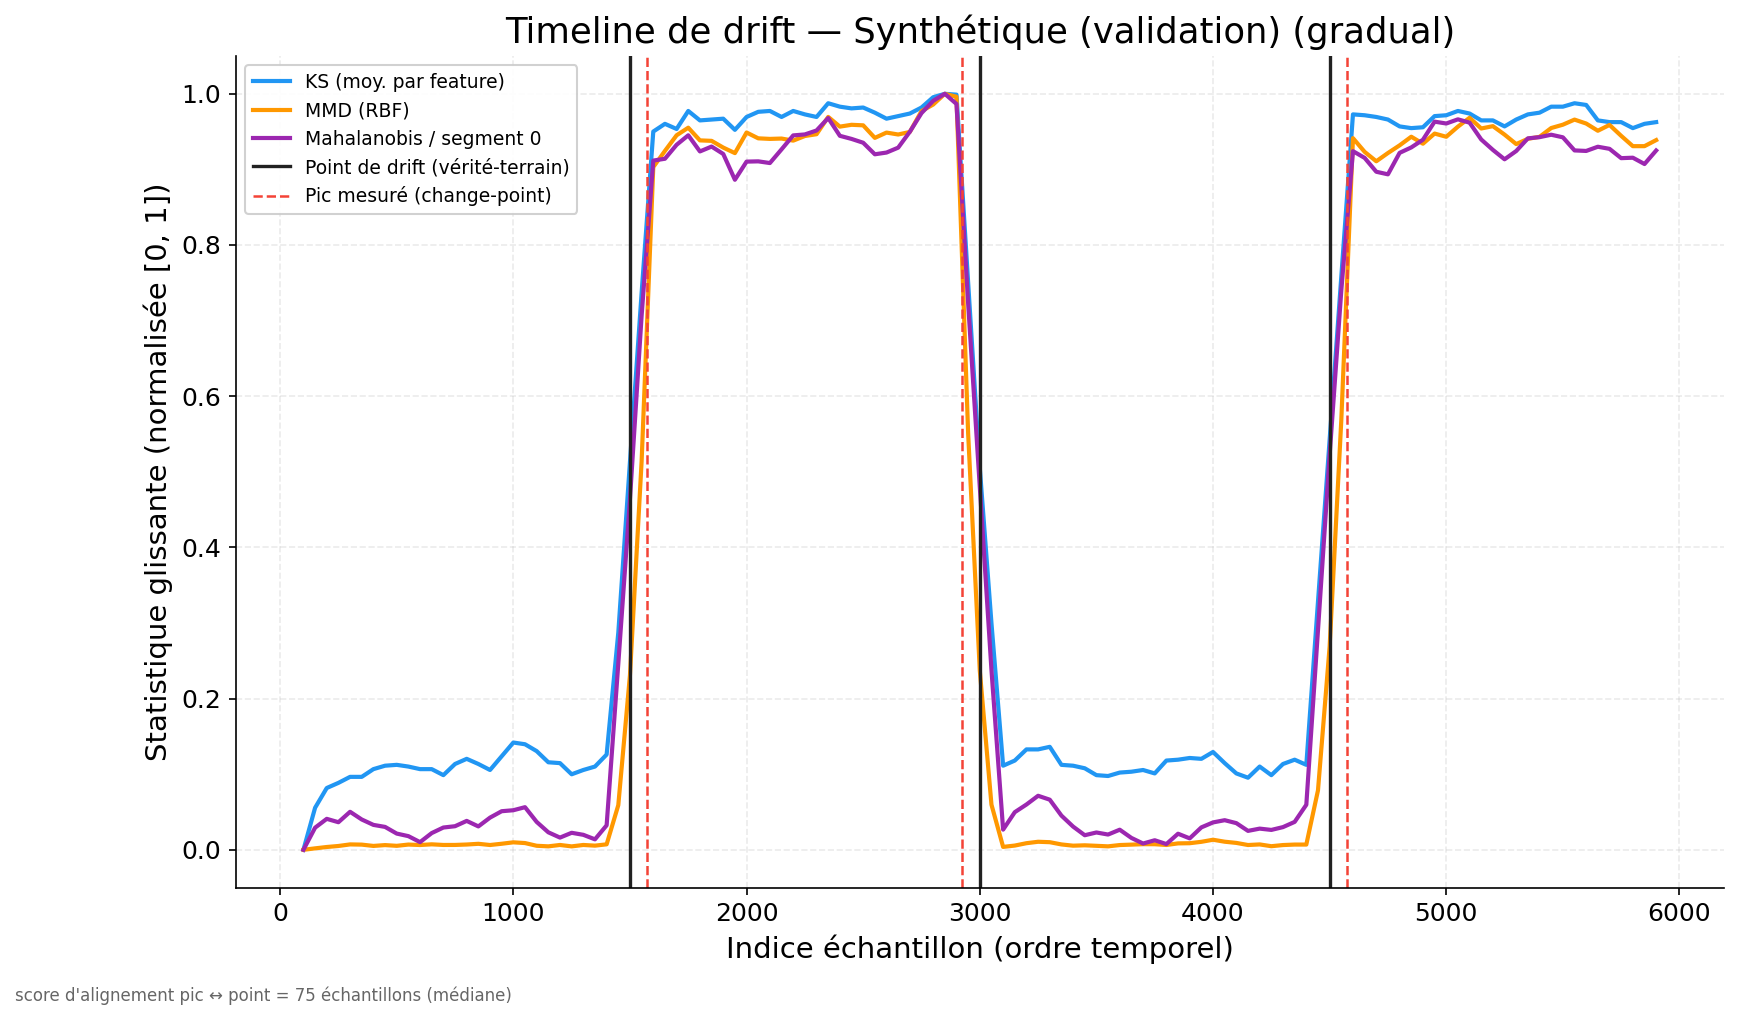

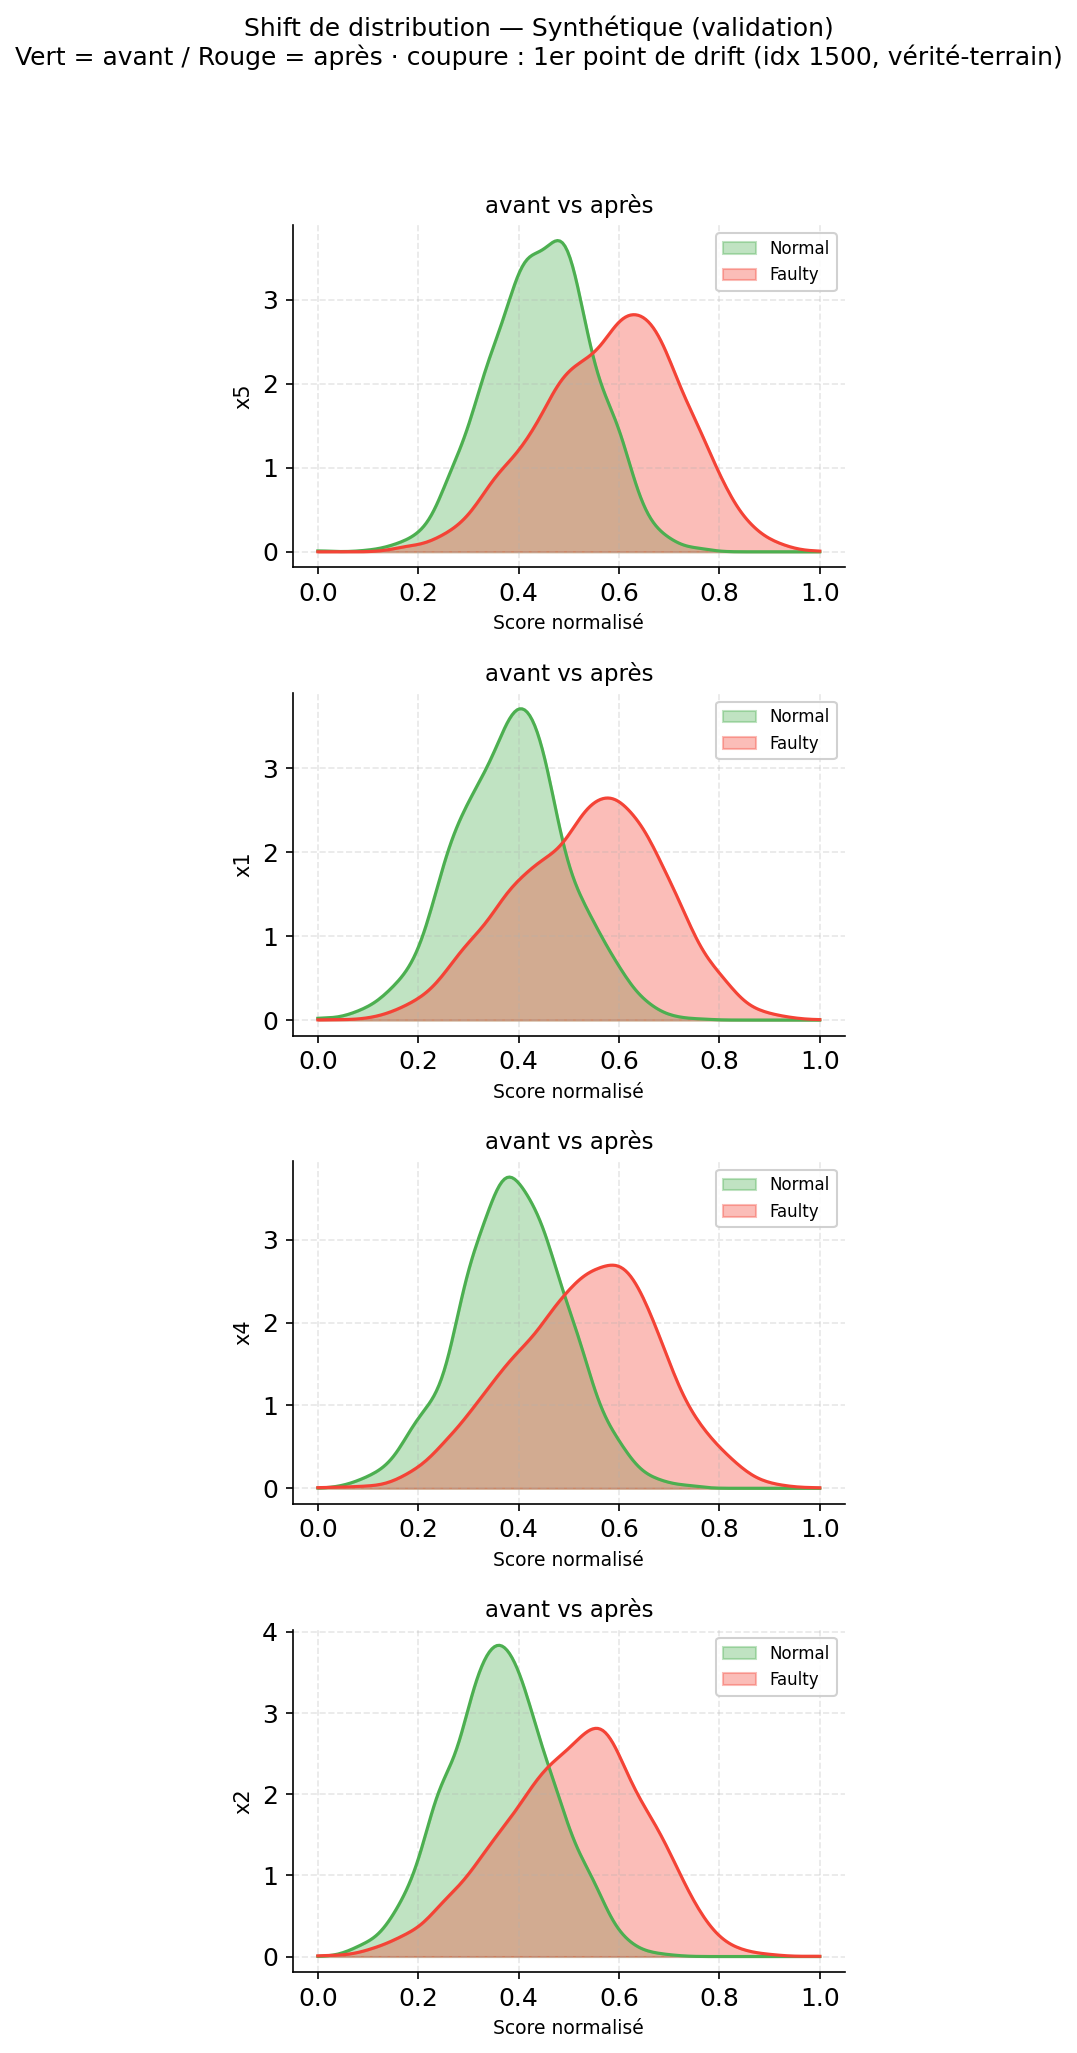

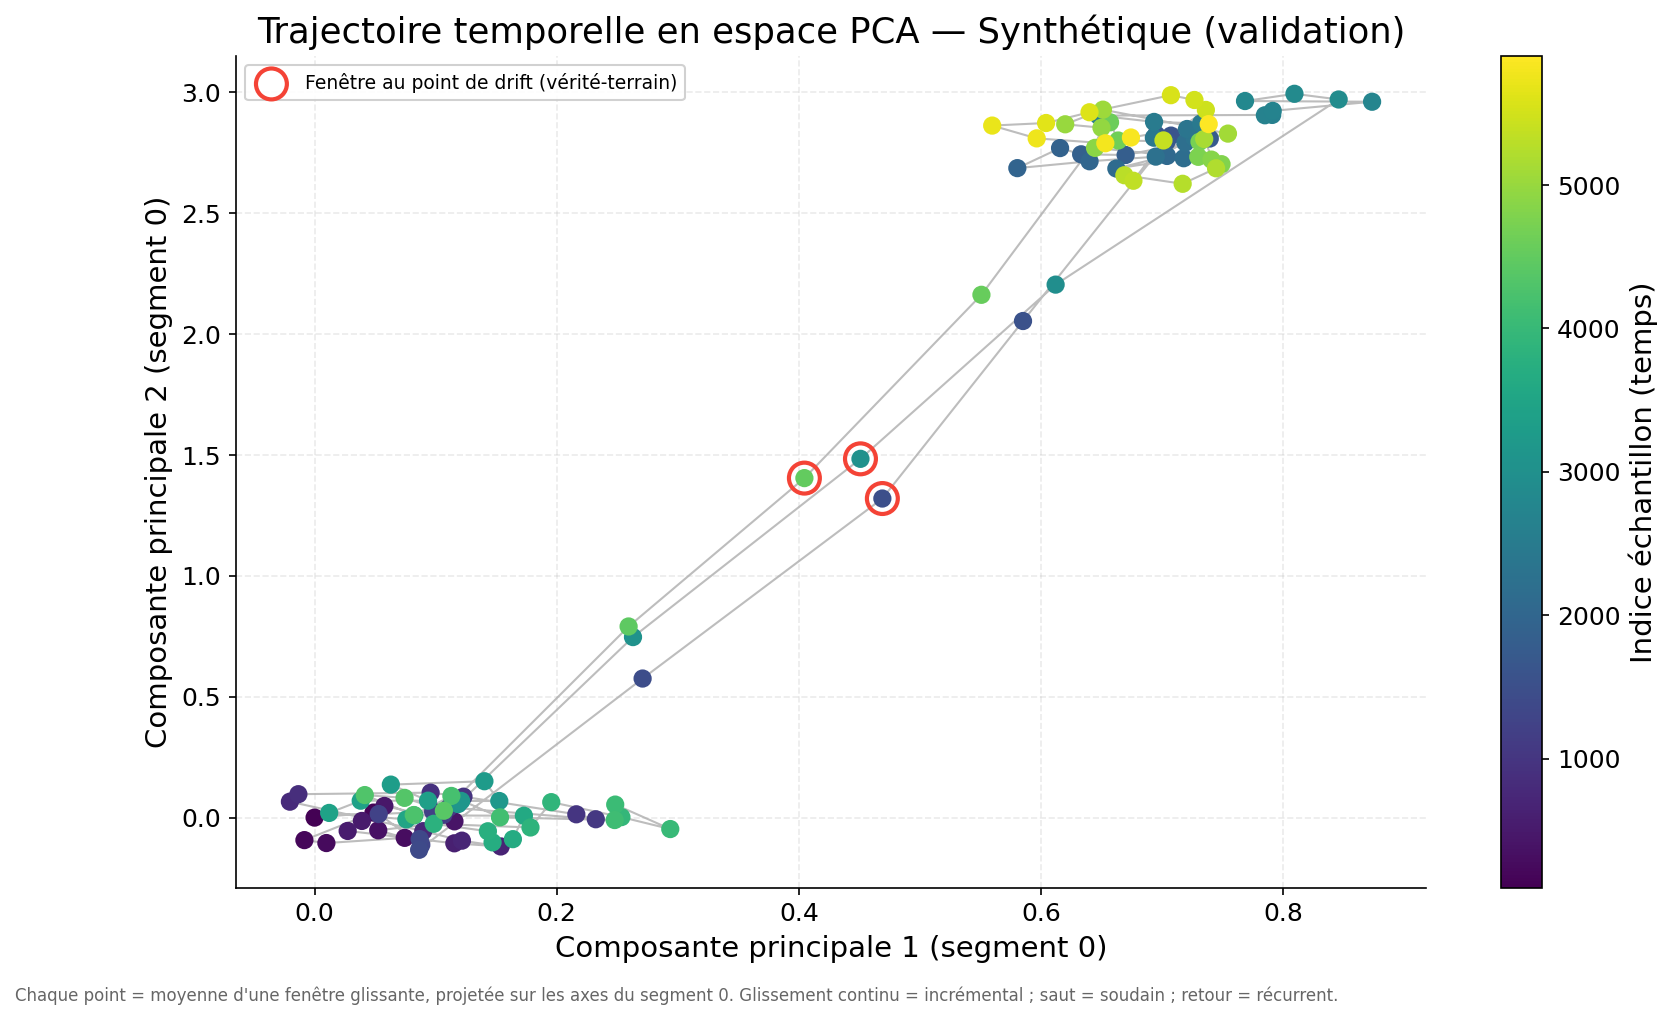

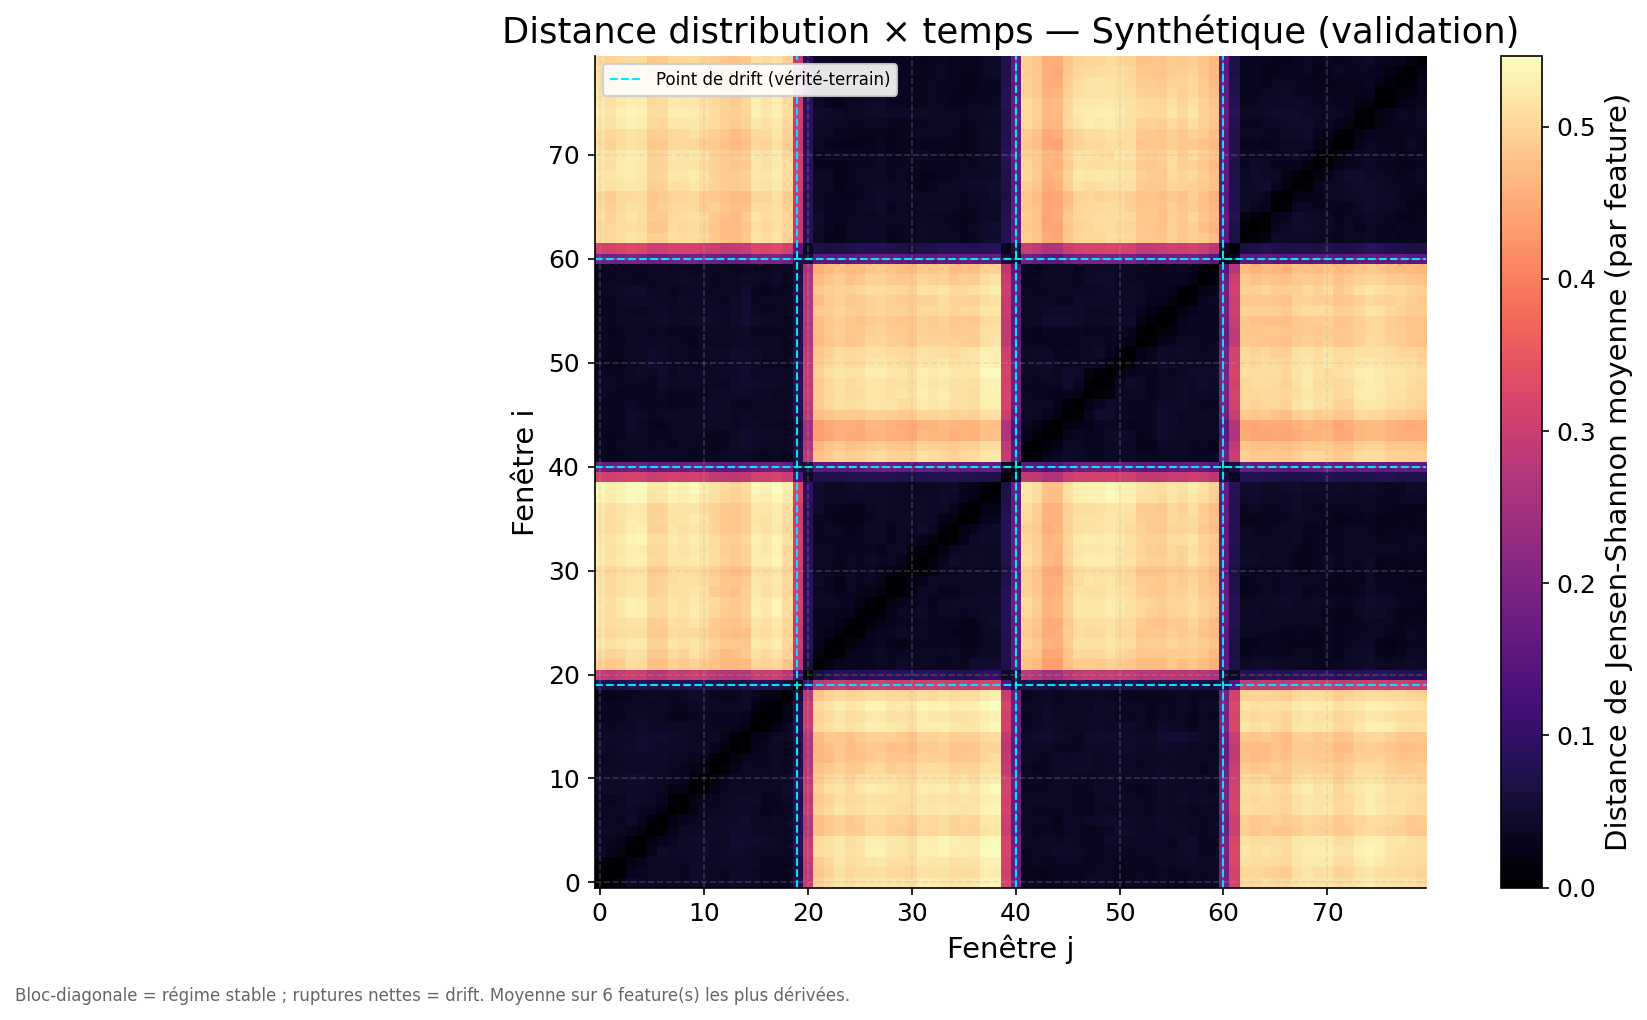

In [2]:
show_dataset("synthetic")

## 2. Gas Sensor Array Drift — dérive incrémentale de capteurs (industriel réel)

**Nature** : 16 capteurs de gaz mesurés sur ~36 mois (10 batches temporels). La dérive physique des capteurs (encrassement, vieillissement) produit un **drift incrémental** documenté : la trajectoire PCA glisse continûment et la distance de Mahalanobis au batch initial croît de batch en batch. Dataset **dual-usage** (classification de 6 gaz) → réutilisable pour évaluer conjointement drift *et* faute.

**Ground-truth** : *structurelle* (frontières de batch), pas d'annotation échantillon-par-échantillon — l'alignement pic ↔ point reste indicatif. C'est le meilleur candidat Gap 1 (capteurs industriels réels).

**Type confirmé** : `incremental` &nbsp;·&nbsp; **n_samples** = 13910 &nbsp;·&nbsp; **n_features** = 128 &nbsp;·&nbsp; **score d'alignement** = 242 échantillons (médiane pic ↔ point)

**drift_points** (vérité-terrain) : `[445, 1689, 3275, 3436, 3633, 5933, 9546, 9840, 10310]`

**Source** : UCI Gas Sensor Array Drift Dataset (Vergara 2012, DOI 10.24432/C5RP6W) &nbsp;·&nbsp; **Licence** : research only (commercial use excluded) &nbsp;·&nbsp; **Ground-truth** : structural (10 temporal batches)

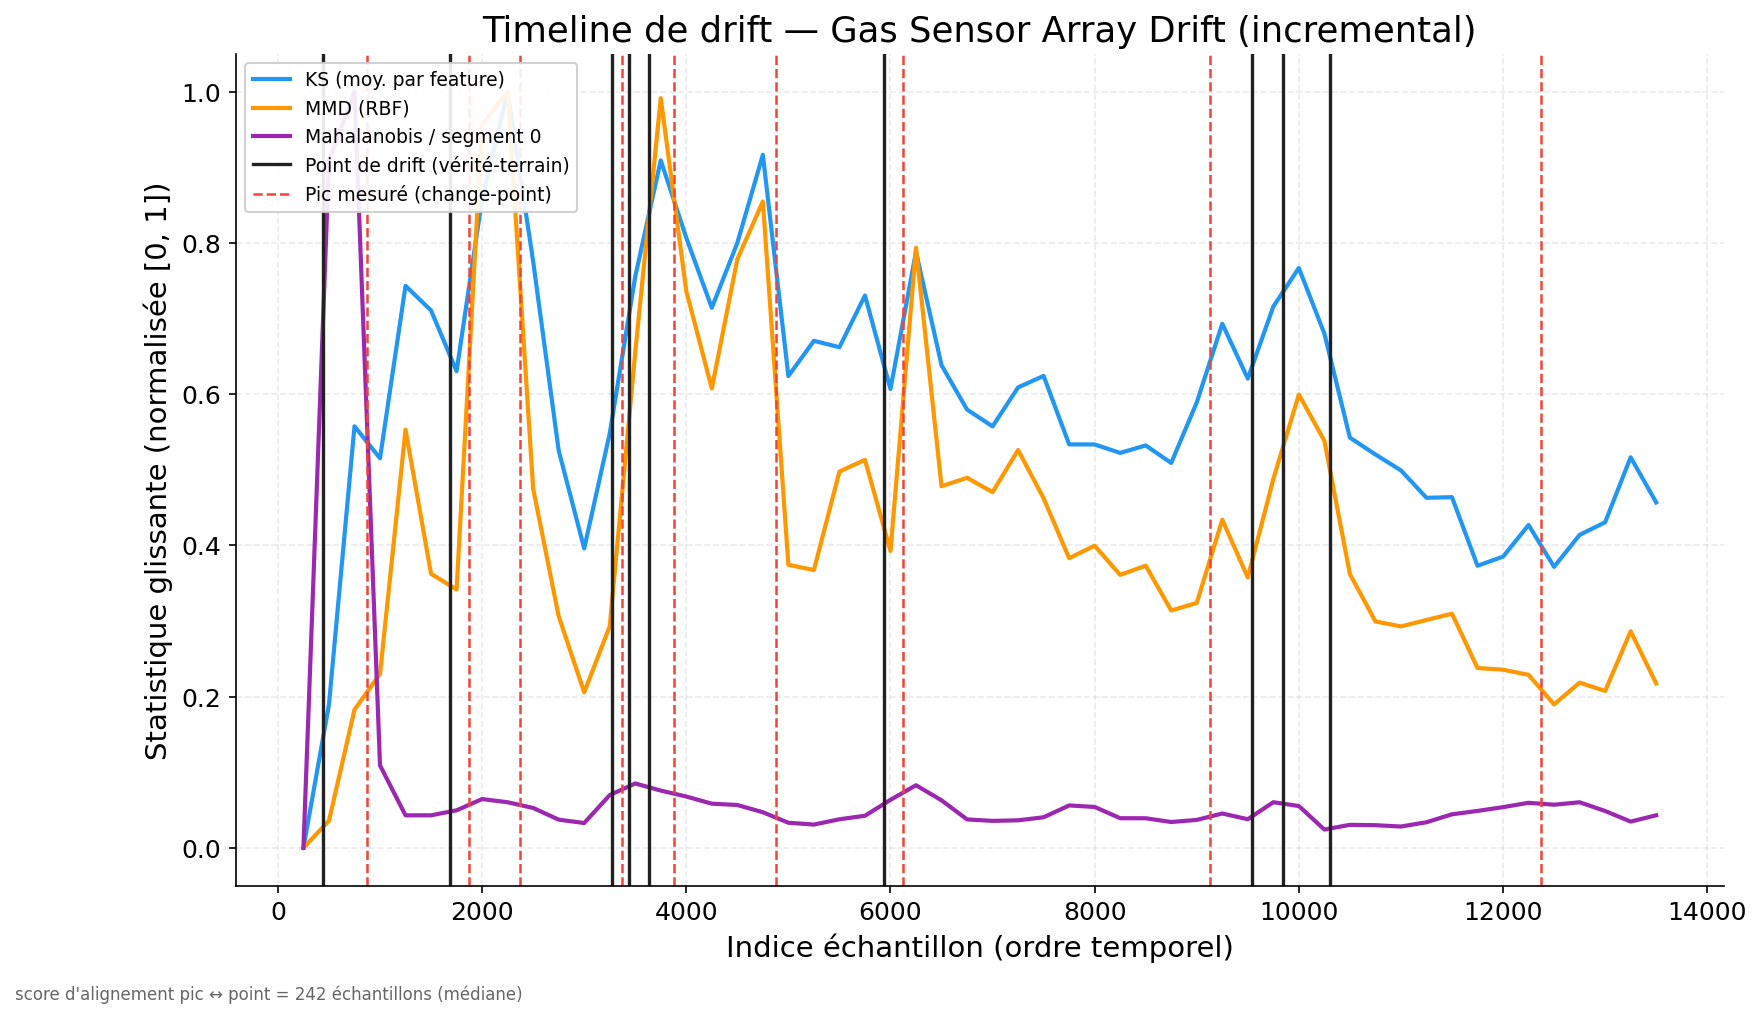

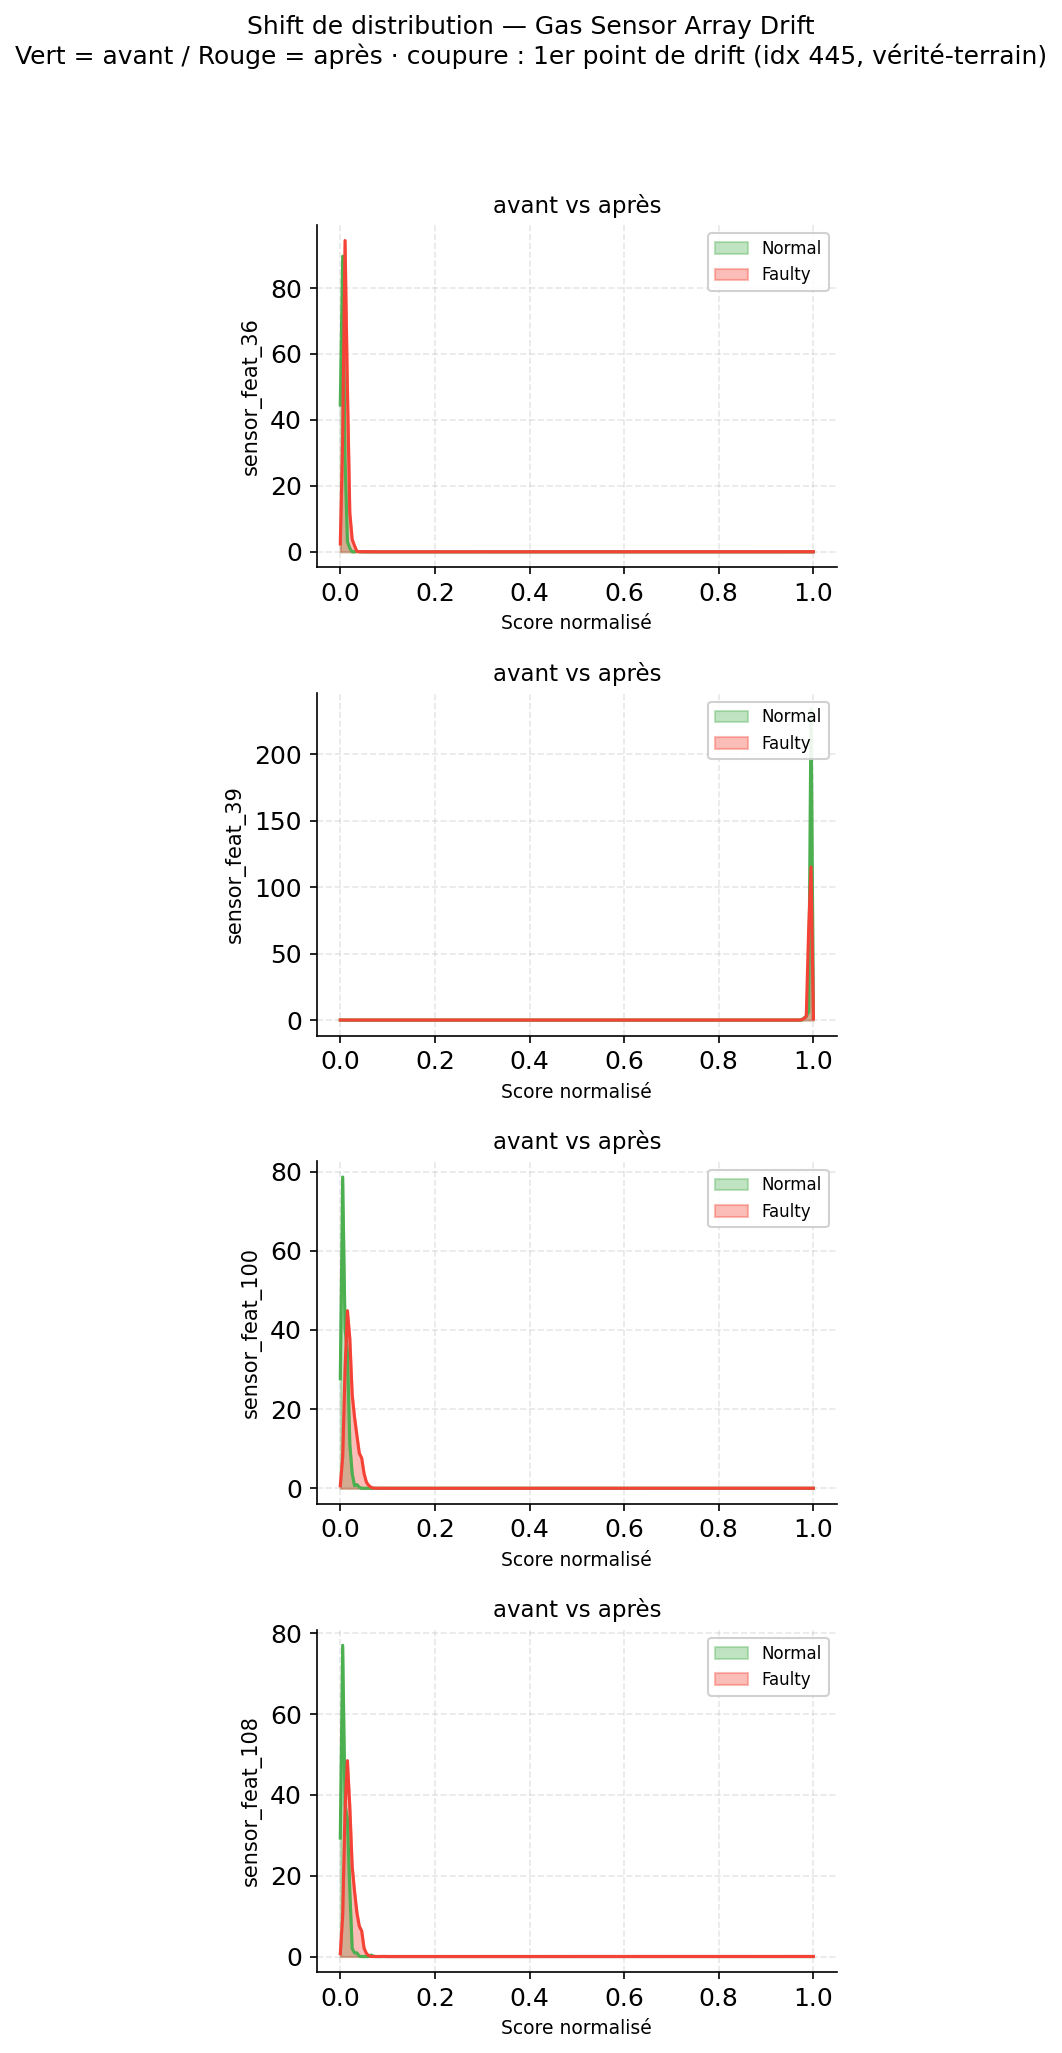

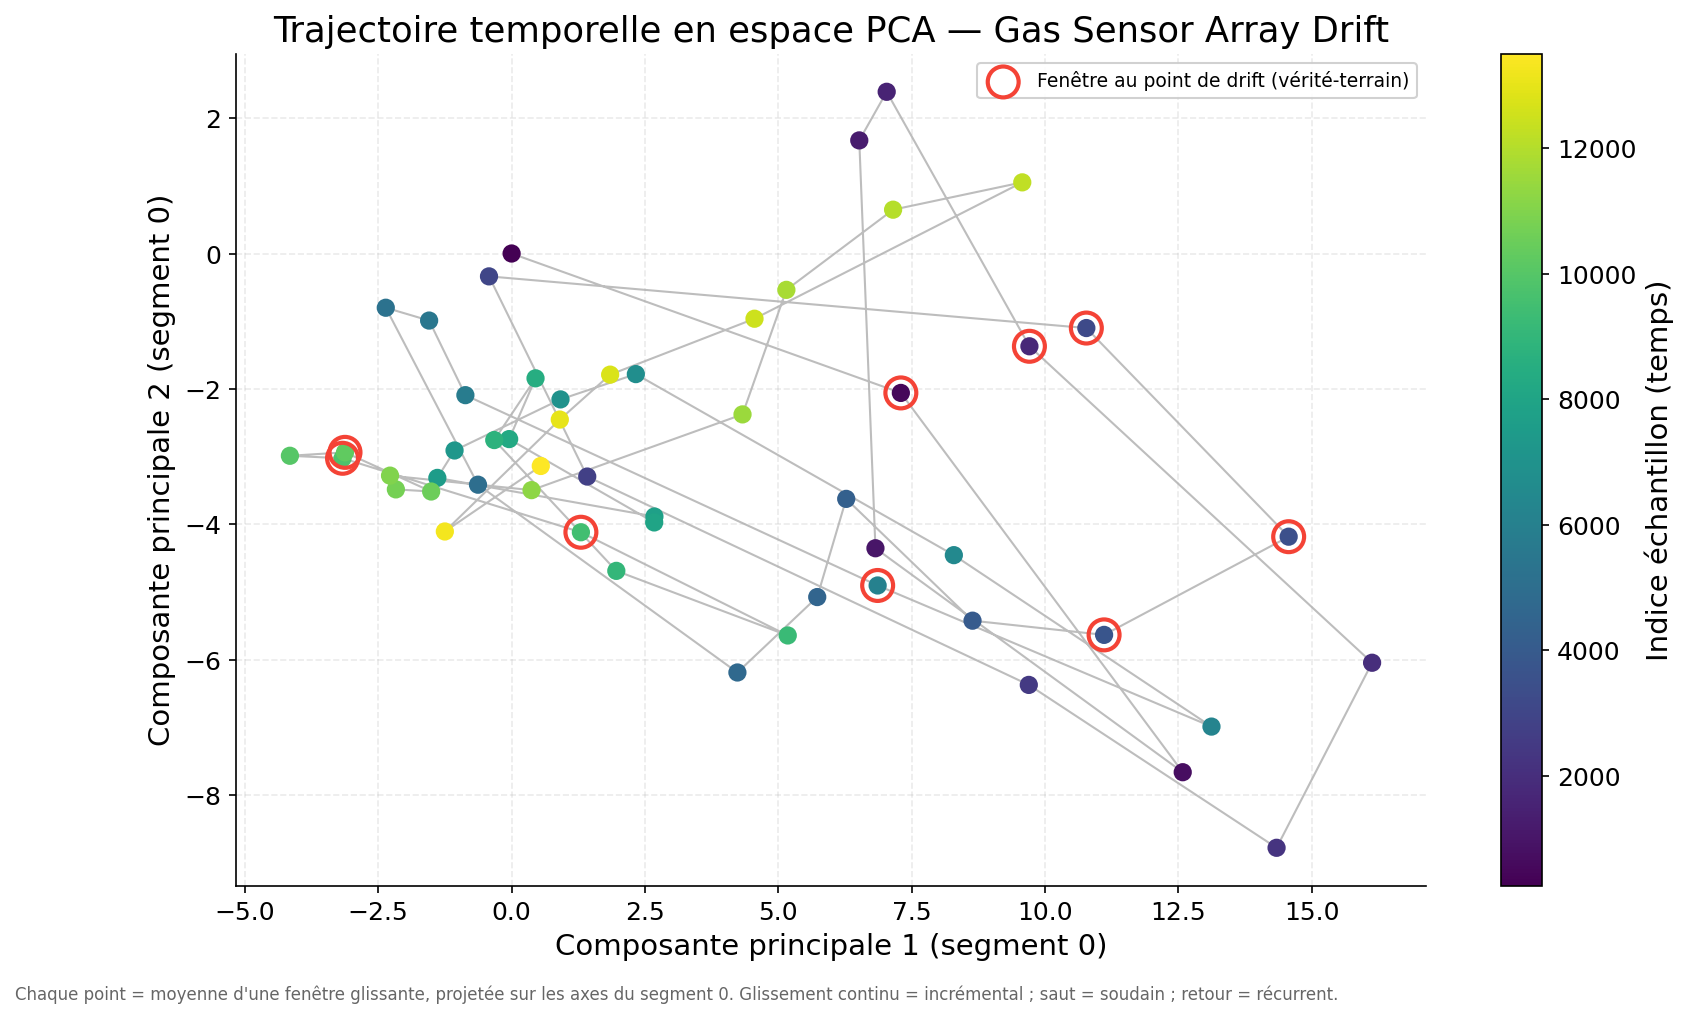

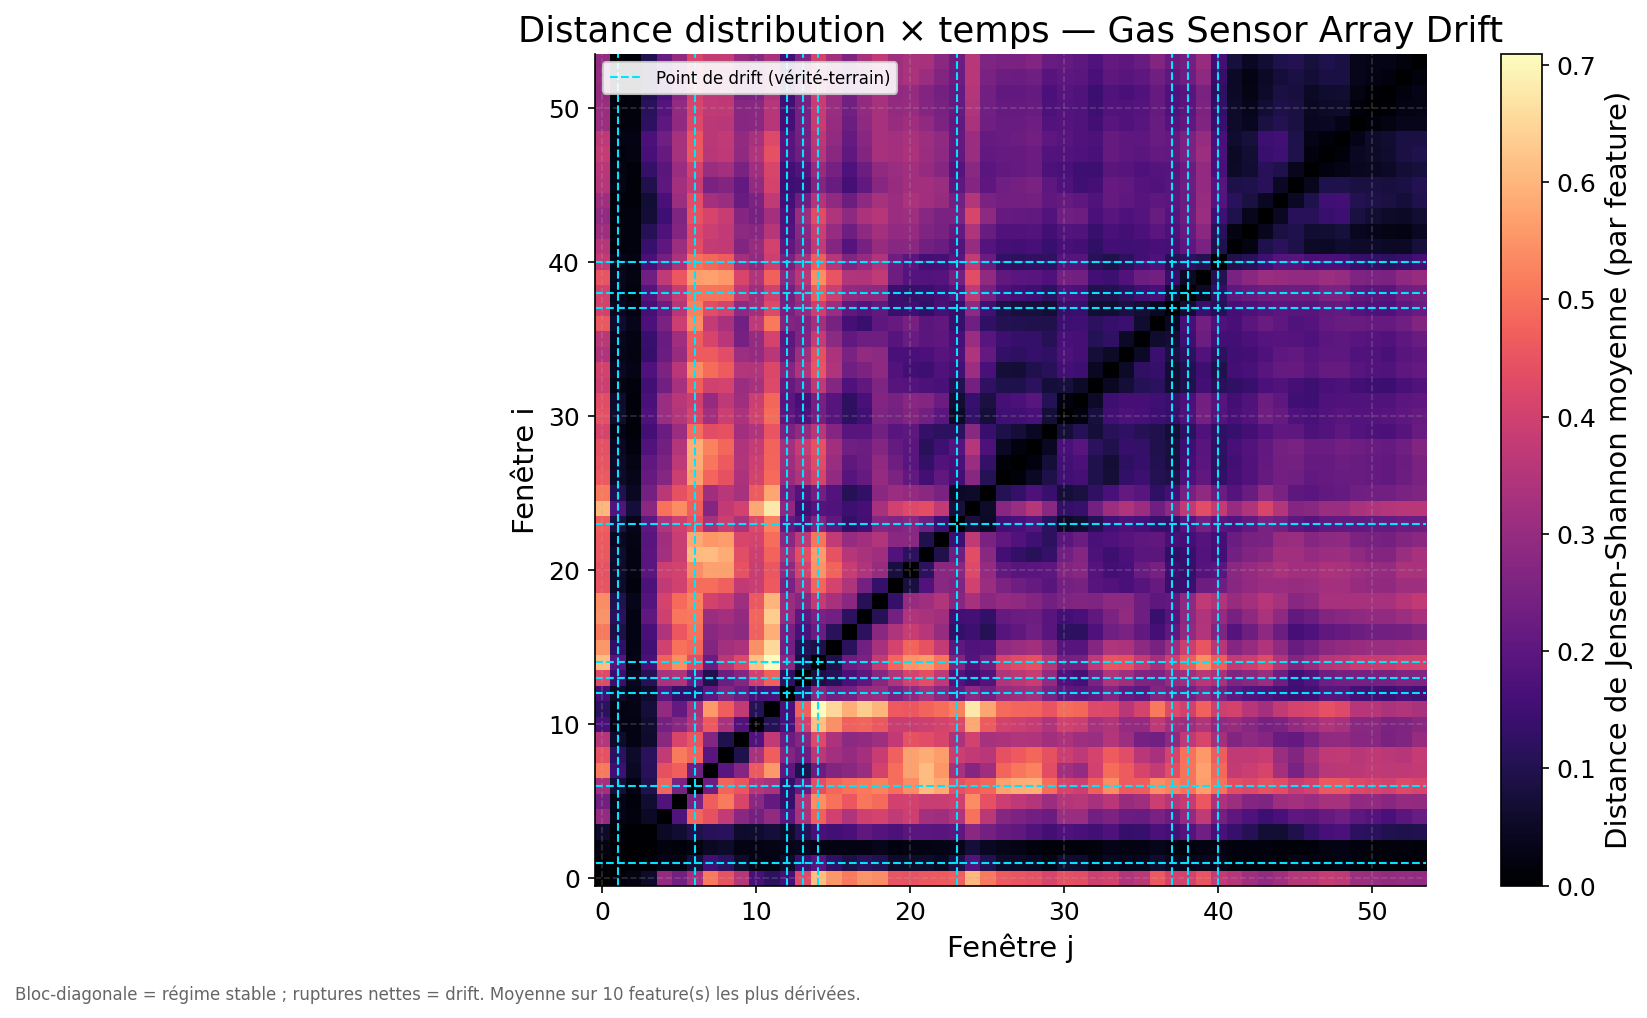

In [3]:
show_dataset("gas_sensor_drift")

## 3. Condition Monitoring Hydraulique — drift de régime segmenté par condition

**Nature** : banc hydraulique ZeMA, segmenté par `cooler_condition`. Le changement de régime de refroidissement décale nettement la distribution des capteurs de pression/température (voir le *shift* avant/après : les modes se séparent fortement). Dataset **dual-usage** (label de stabilité / faute).

**Ground-truth** : *structurelle* (frontières de segment de condition). Utile pour tester un détecteur de drift sur des ruptures de régime franches.

**Type confirmé** : `incremental` &nbsp;·&nbsp; **n_samples** = 2205 &nbsp;·&nbsp; **n_features** = 17 &nbsp;·&nbsp; **score d'alignement** = 152 échantillons (médiane pic ↔ point)

**drift_points** (vérité-terrain) : `[732, 1464]`

**Source** : Condition Monitoring of Hydraulic Systems (ZeMA gGmbH / UCI, 2018) &nbsp;·&nbsp; **Licence** : research use (ZeMA gGmbH) &nbsp;·&nbsp; **Ground-truth** : structural (segmented by cooler_condition)

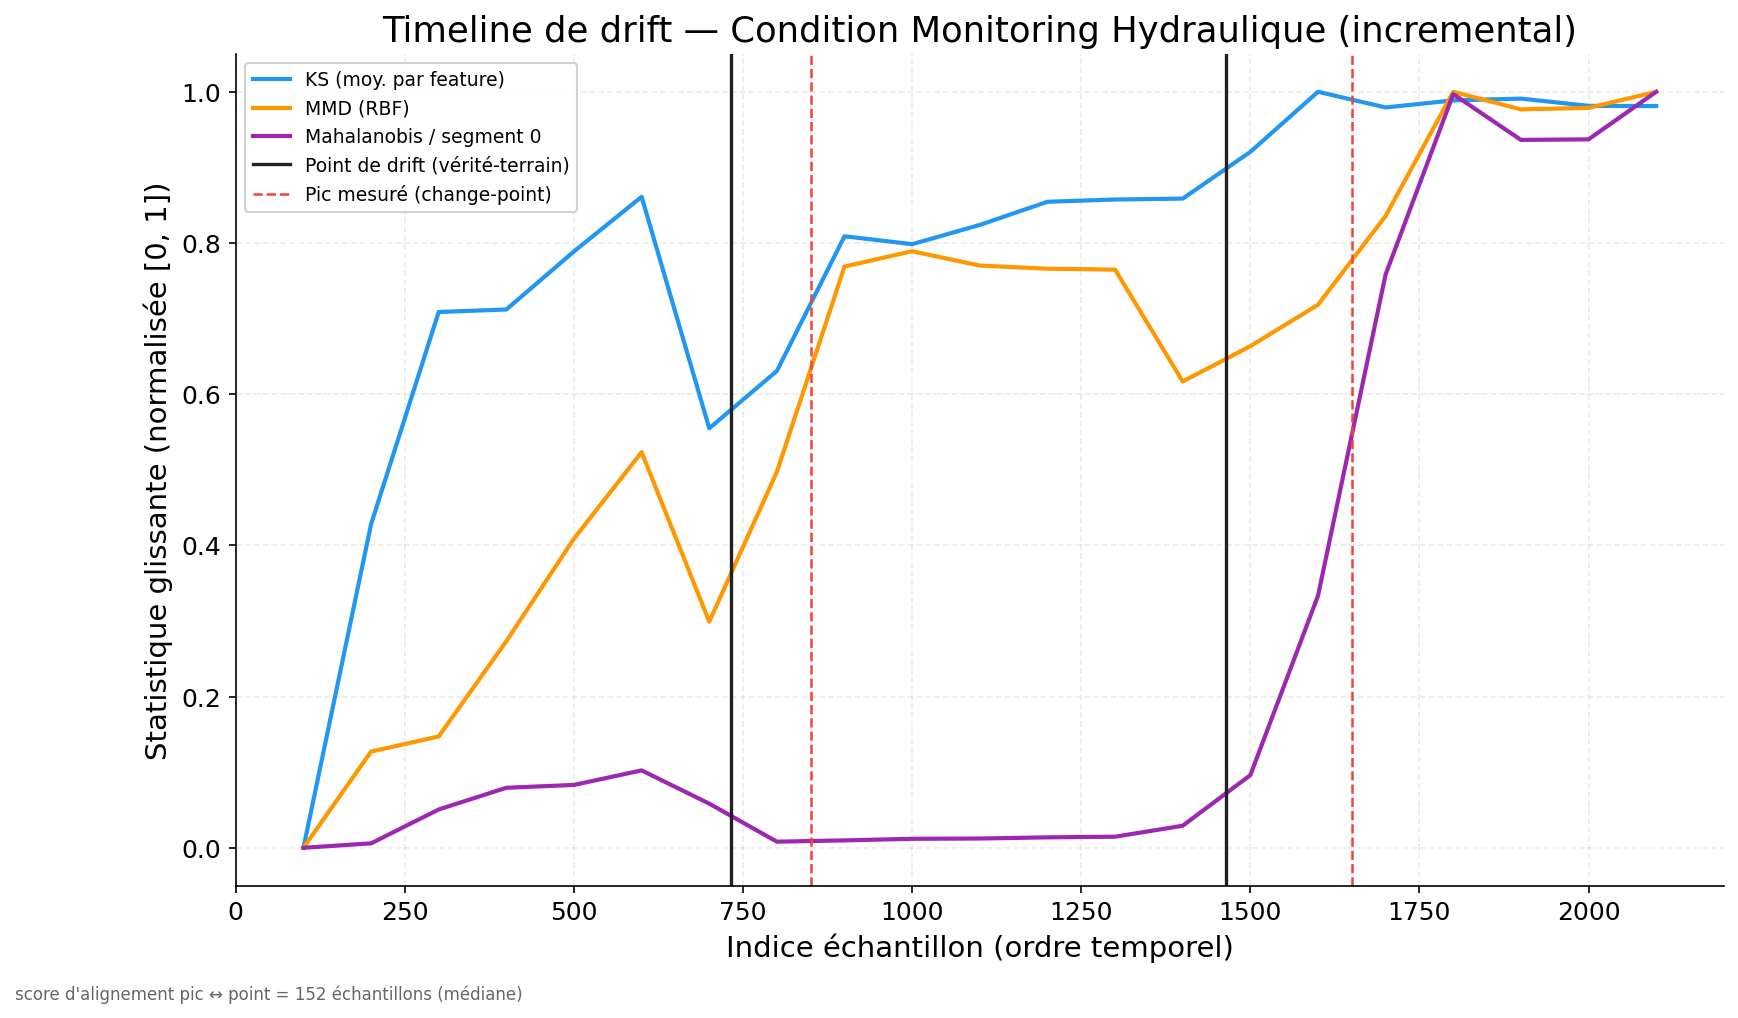

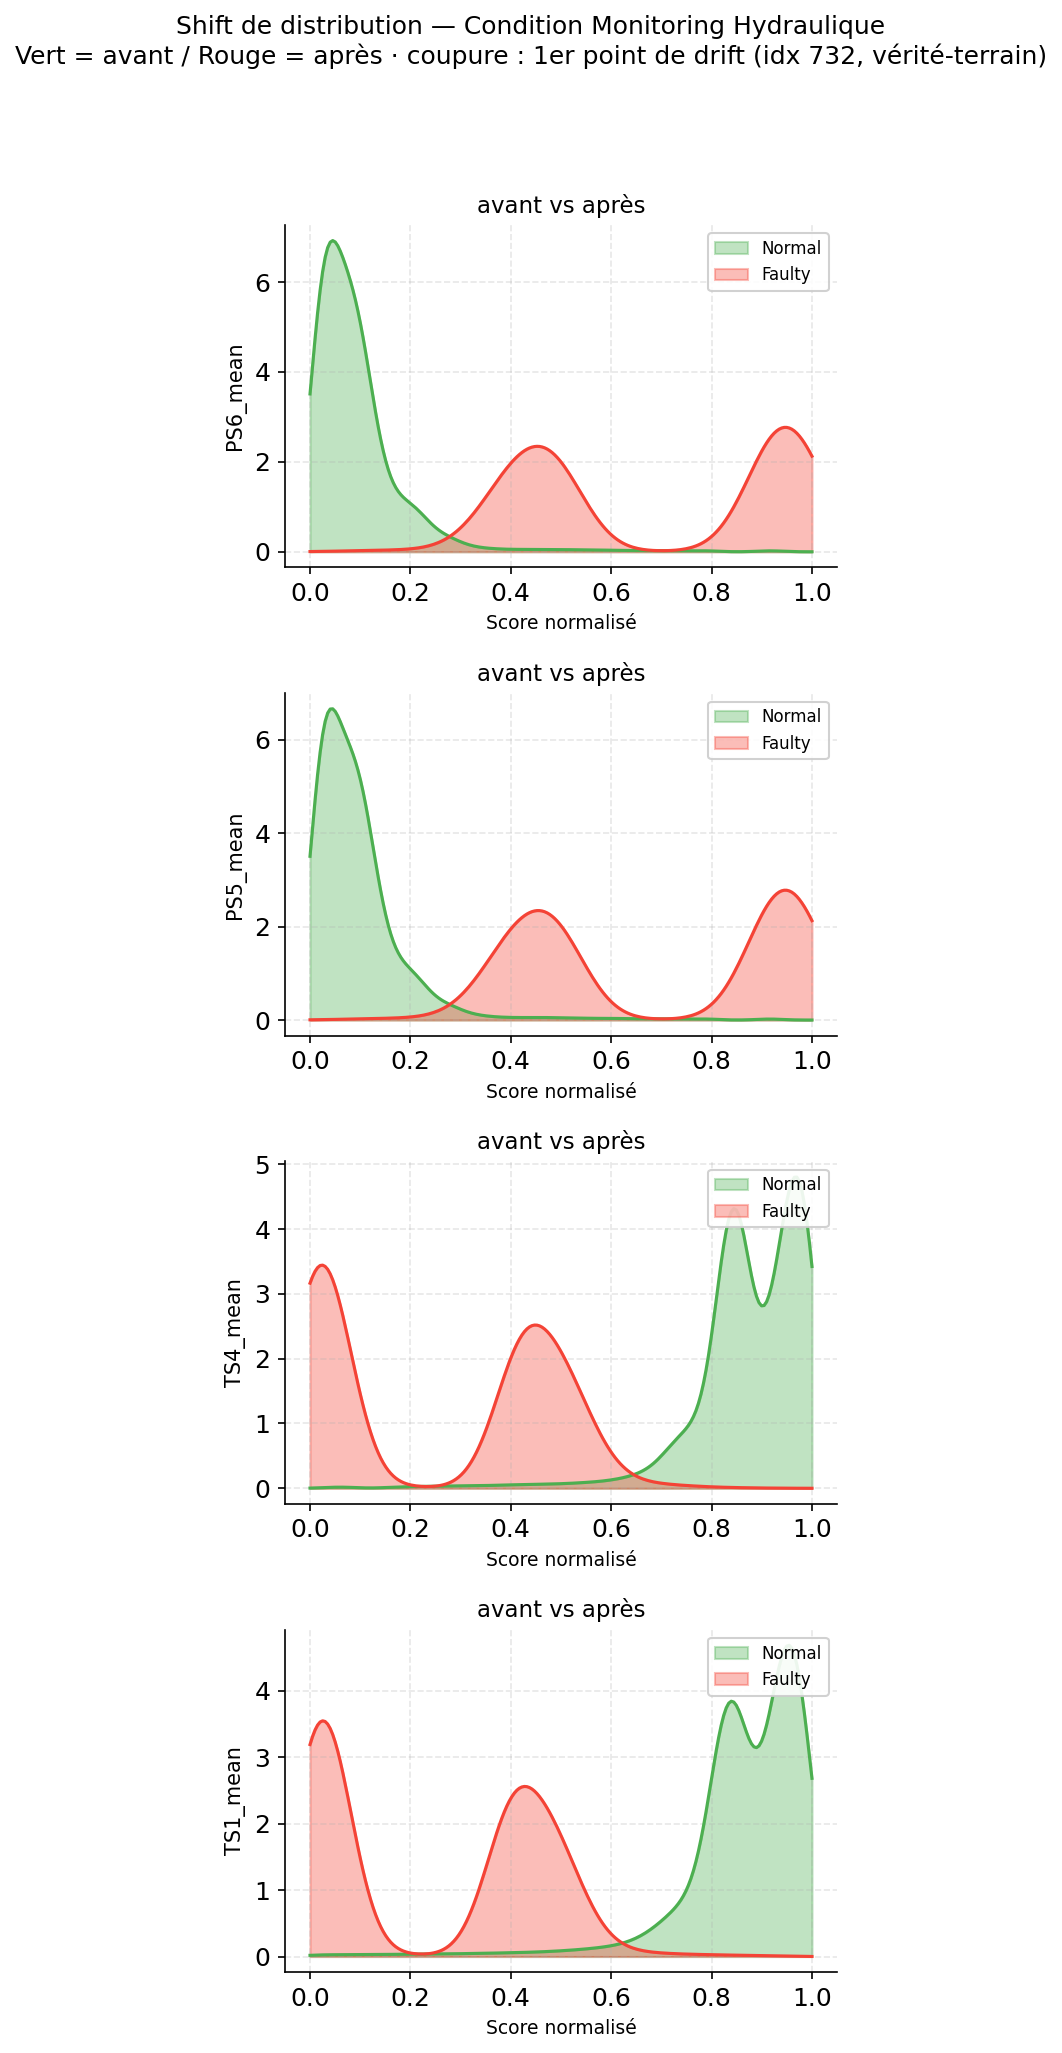

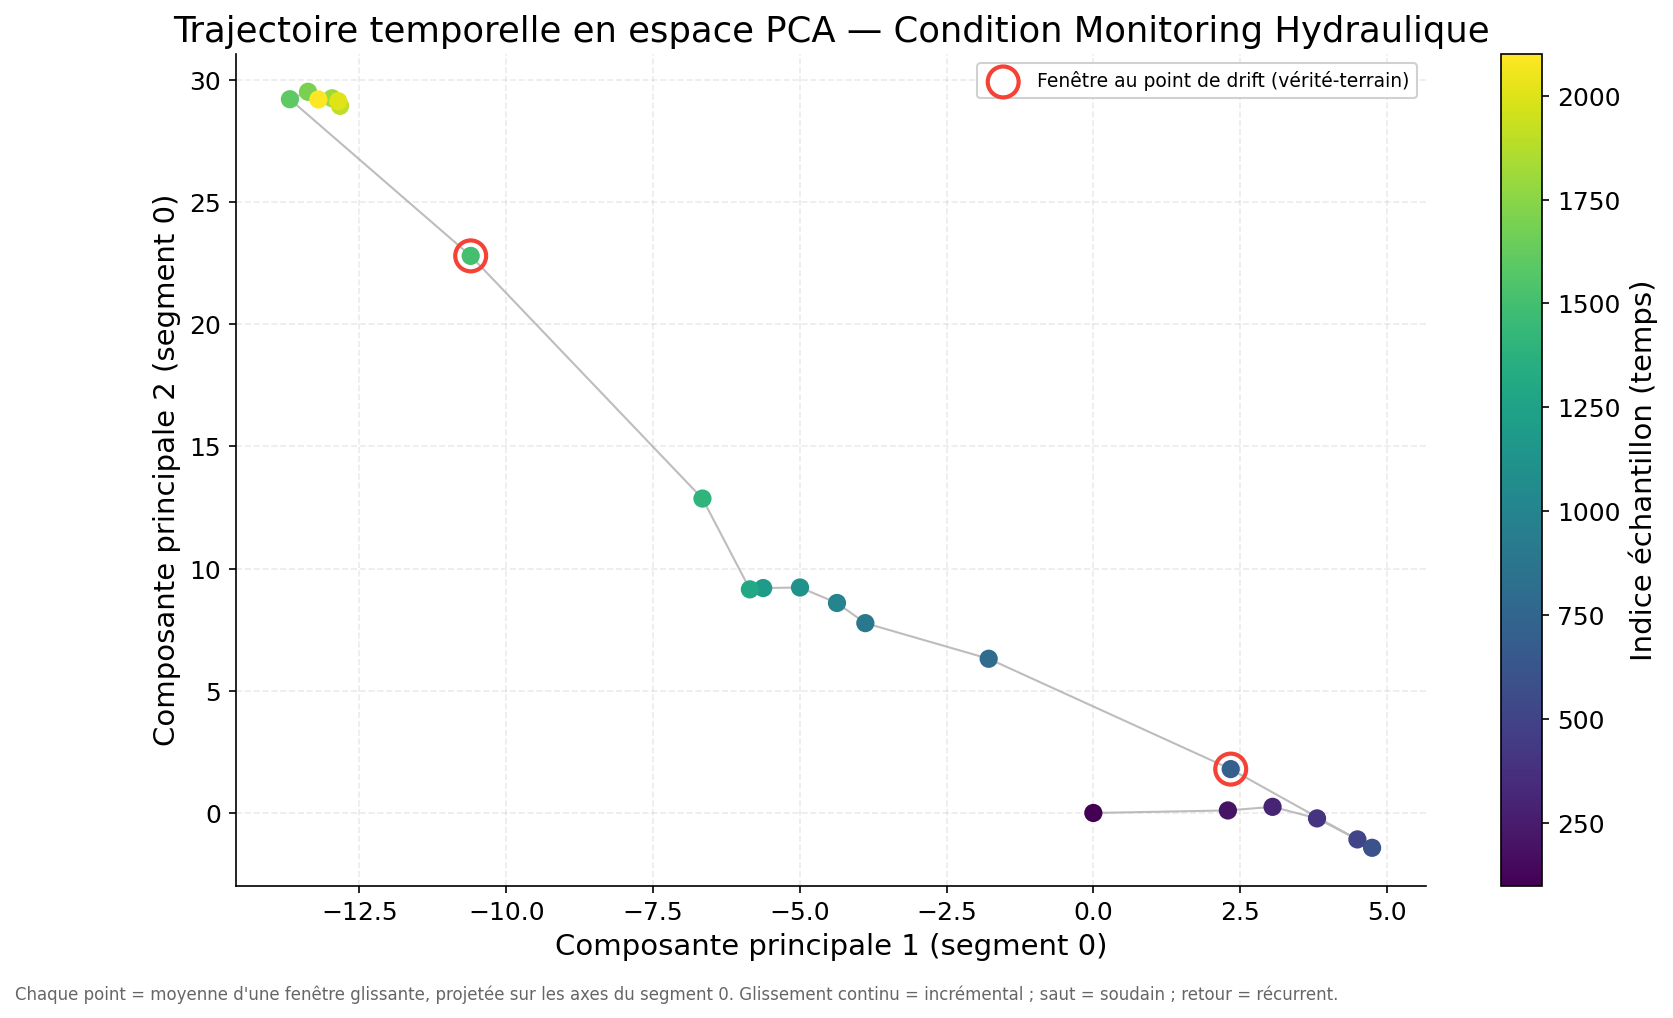

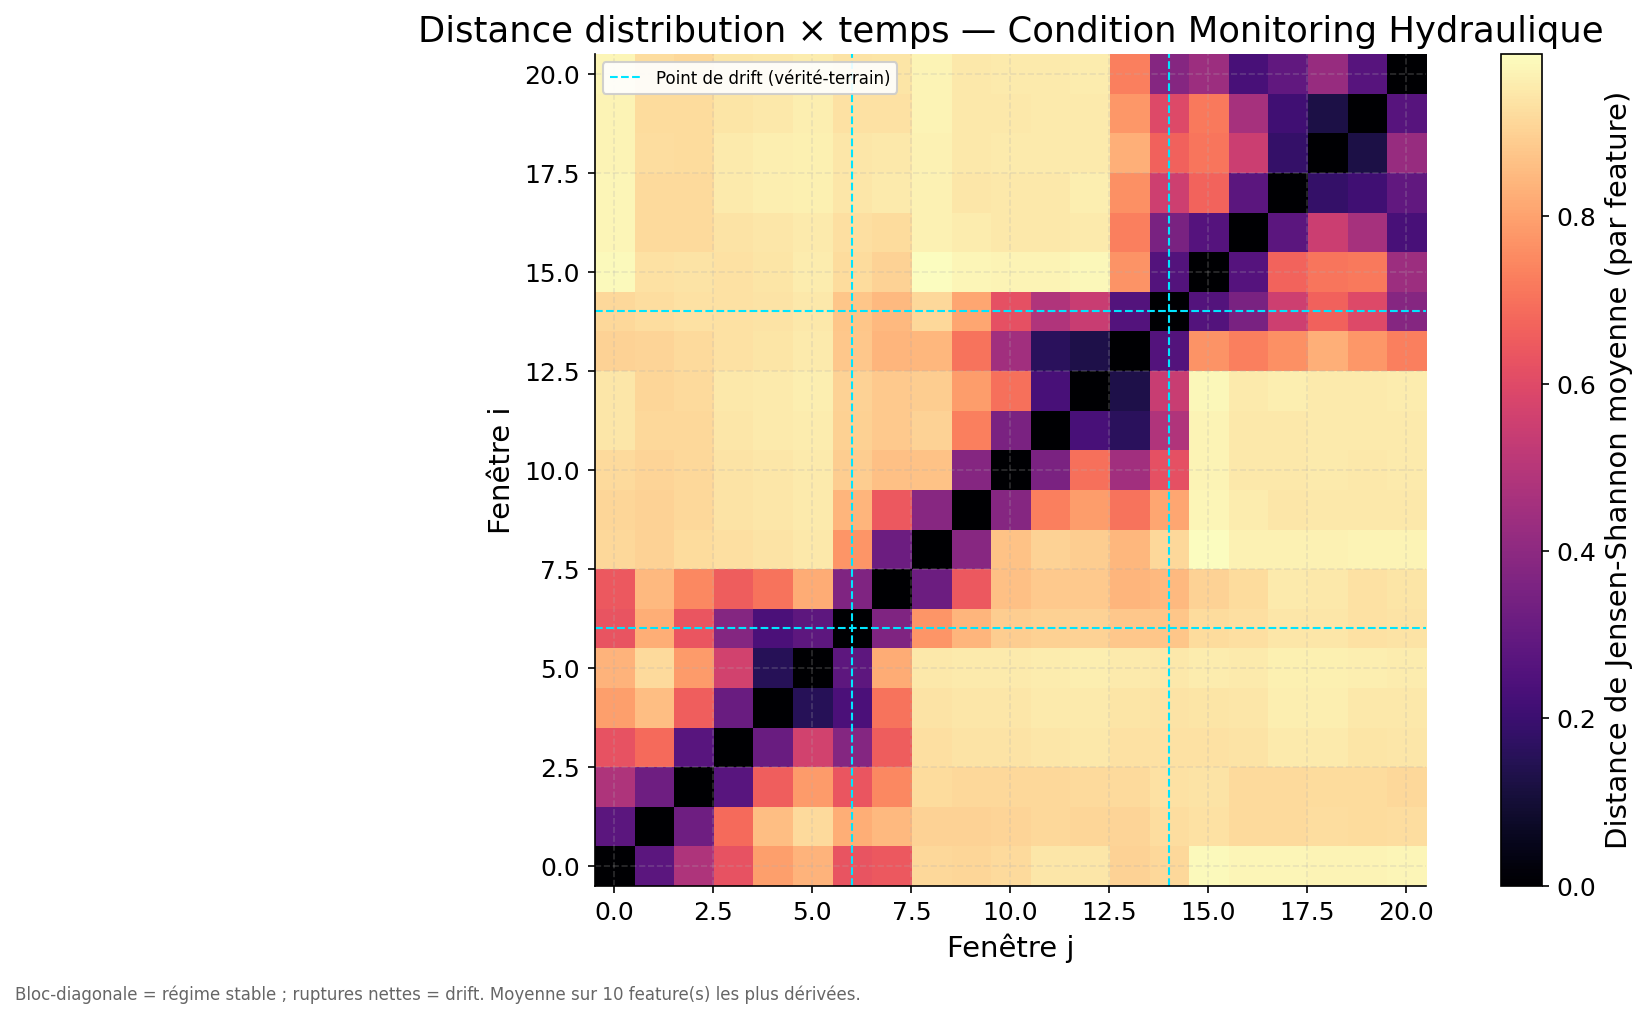

In [4]:
show_dataset("hydraulic")

## 4. Electricity (ELEC2) — concept drift sans point ponctuel

**Nature** : benchmark concept-drift classique (marché électrique). Le drift est établi dans la littérature mais **non ponctuel** : aucune annotation d'instant de rupture. Le loader retourne donc `drift_points = None` et le `alignment_score` est `null` — un choix **honnête** (on ne fabrique pas de vérité-terrain).

**Rôle** : cas limite pour tester la robustesse d'un détecteur en l'absence de vérité-terrain ponctuelle (évaluation par proxy supervisé uniquement). Non dual-usage faute.

**Type confirmé** : `gradual` &nbsp;·&nbsp; **n_samples** = 45312 &nbsp;·&nbsp; **n_features** = 7 &nbsp;·&nbsp; **score d'alignement** = n/a (ground-truth non ponctuelle)

**drift_points** (vérité-terrain) : `None`

**Source** : ELEC2 (Harries 1999; Gama 2004; normalized by Bifet) &nbsp;·&nbsp; **Licence** : public / research use &nbsp;·&nbsp; **Ground-truth** : none (structural drift established in literature, no exact points)

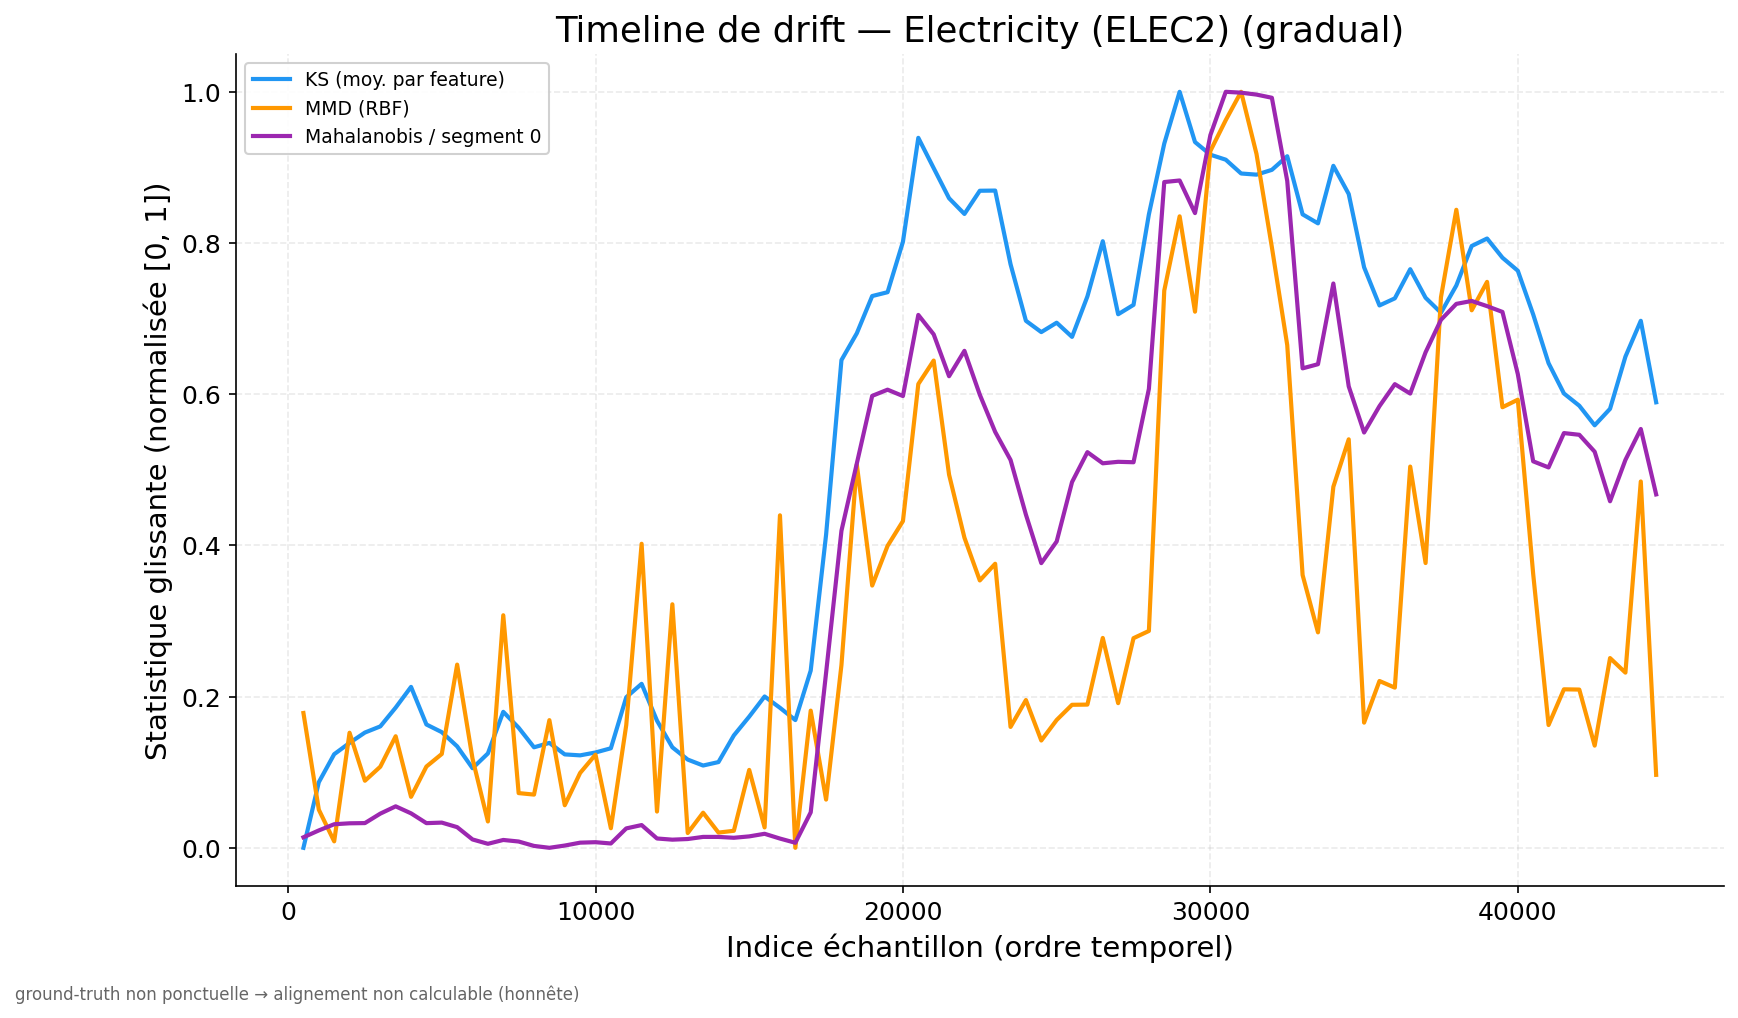

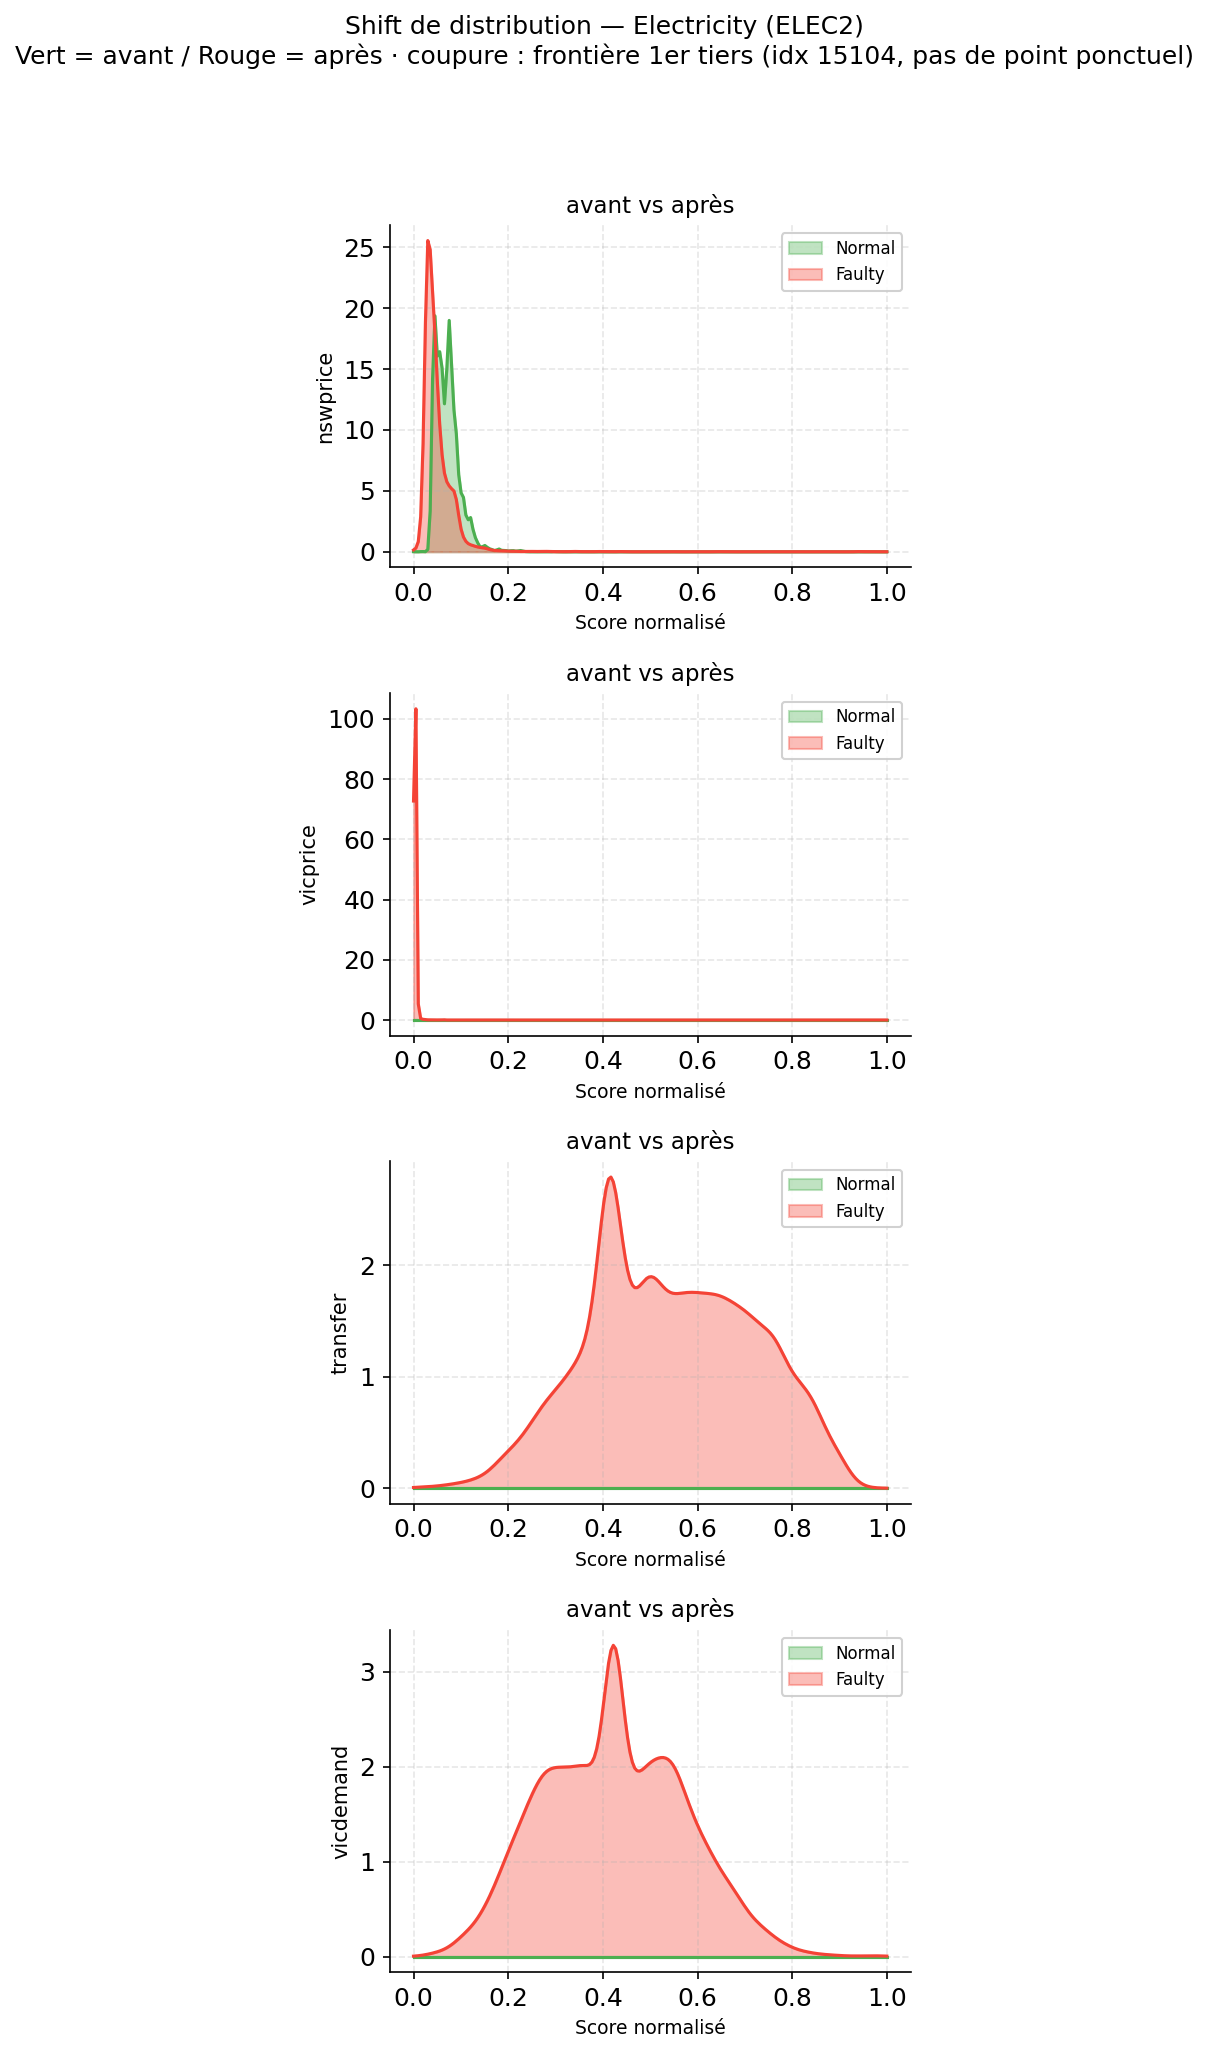

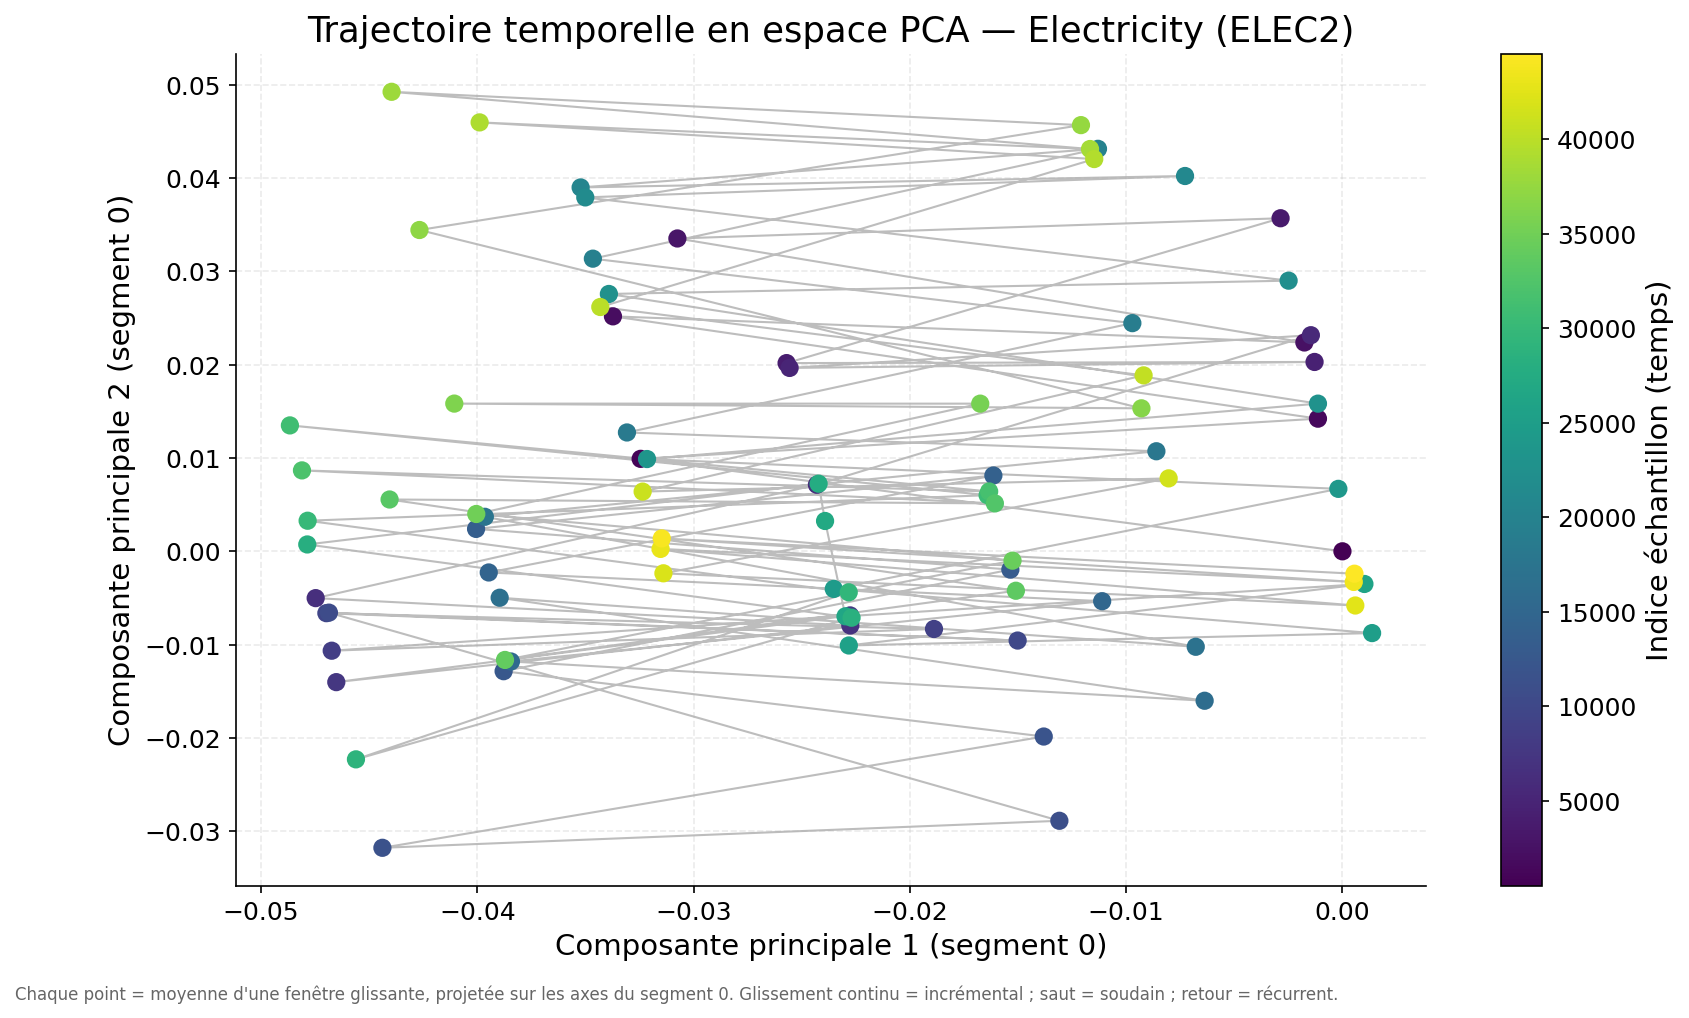

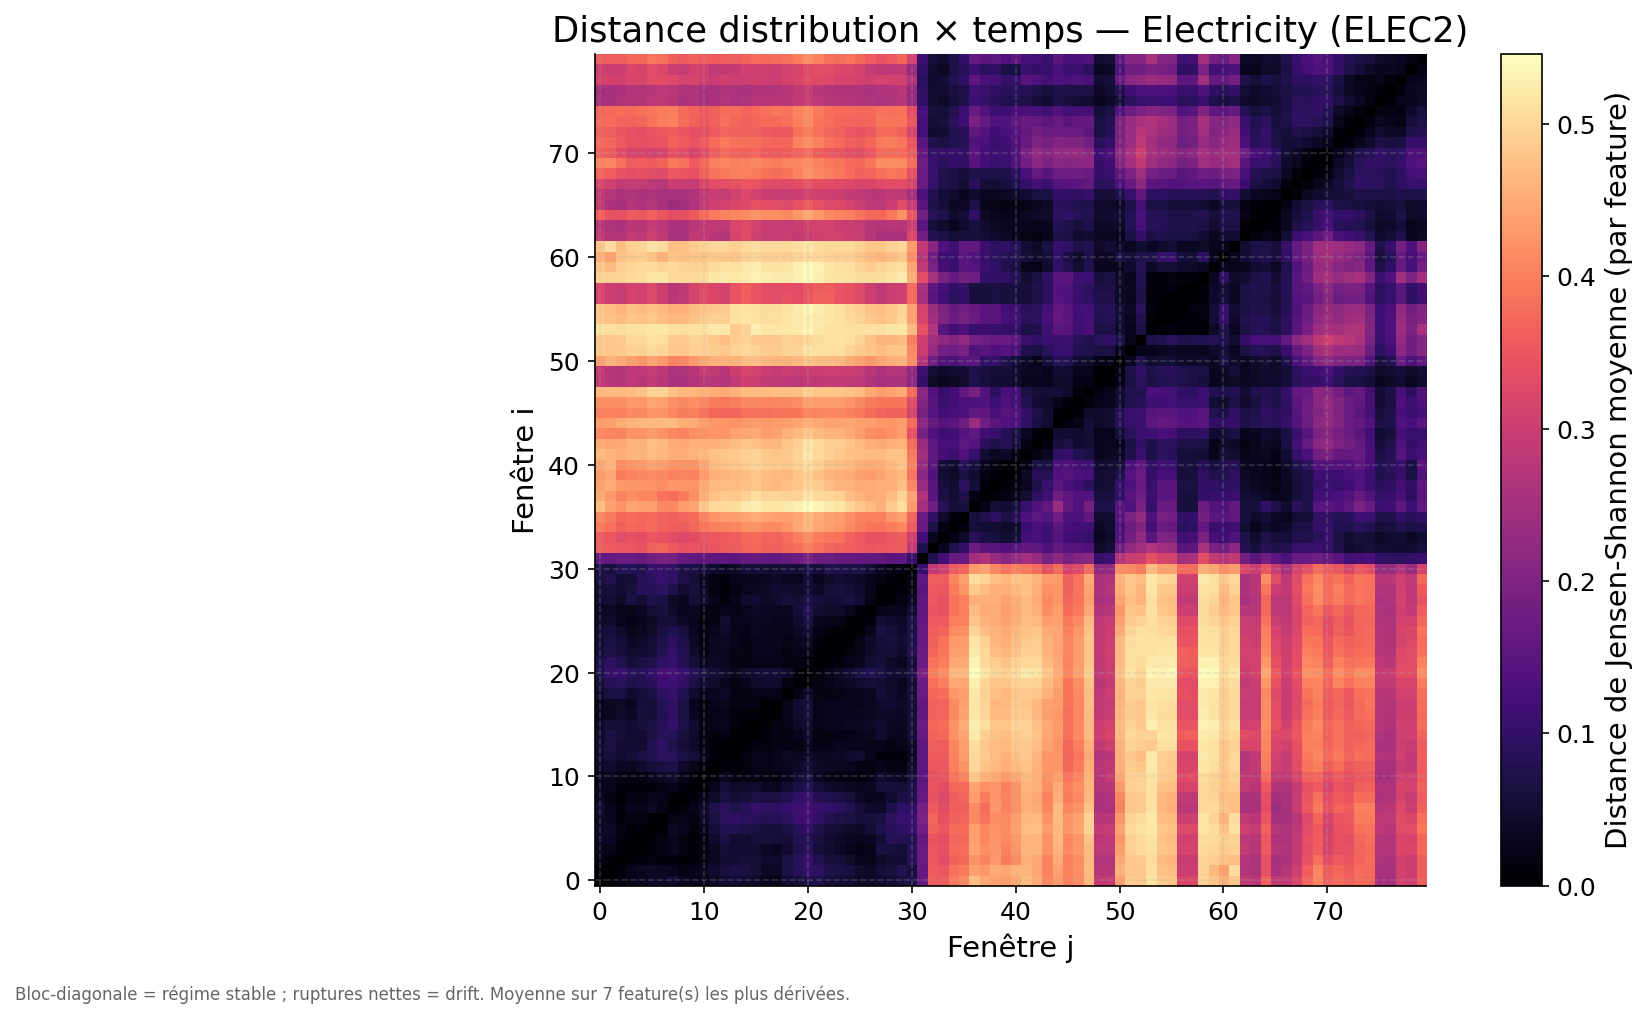

In [5]:
show_dataset("electricity")

## Comparatif transverse

Tableau récapitulatif construit **depuis les JSON de caractérisation** (aucune valeur inline). Il justifie la diversité du corpus : types de drift variés (récurrent, incrémental, régime), granularités de ground-truth différentes (exacte / structurelle / absente), dimensions de features contrastées (impact direct sur l'état mémoire porté board en S45).

,drift_type,n_samples,n_features,n_drift_points,alignment_score,ground_truth,licence
dataset,,,,,,,
synthetic,gradual,6000,6,3,75.0,exact (drift_points imposed by construction),n/a (generated on-the-fly)
gas_sensor_drift,incremental,13910,128,9,242.0,structural (10 temporal batches),research only (commercial use excluded)
hydraulic,incremental,2205,17,2,152.0,structural (segmented by cooler_condition),research use (ZeMA gGmbH)
electricity,gradual,45312,7,0,NaN,none (structural drift established in literatu...,public / research use


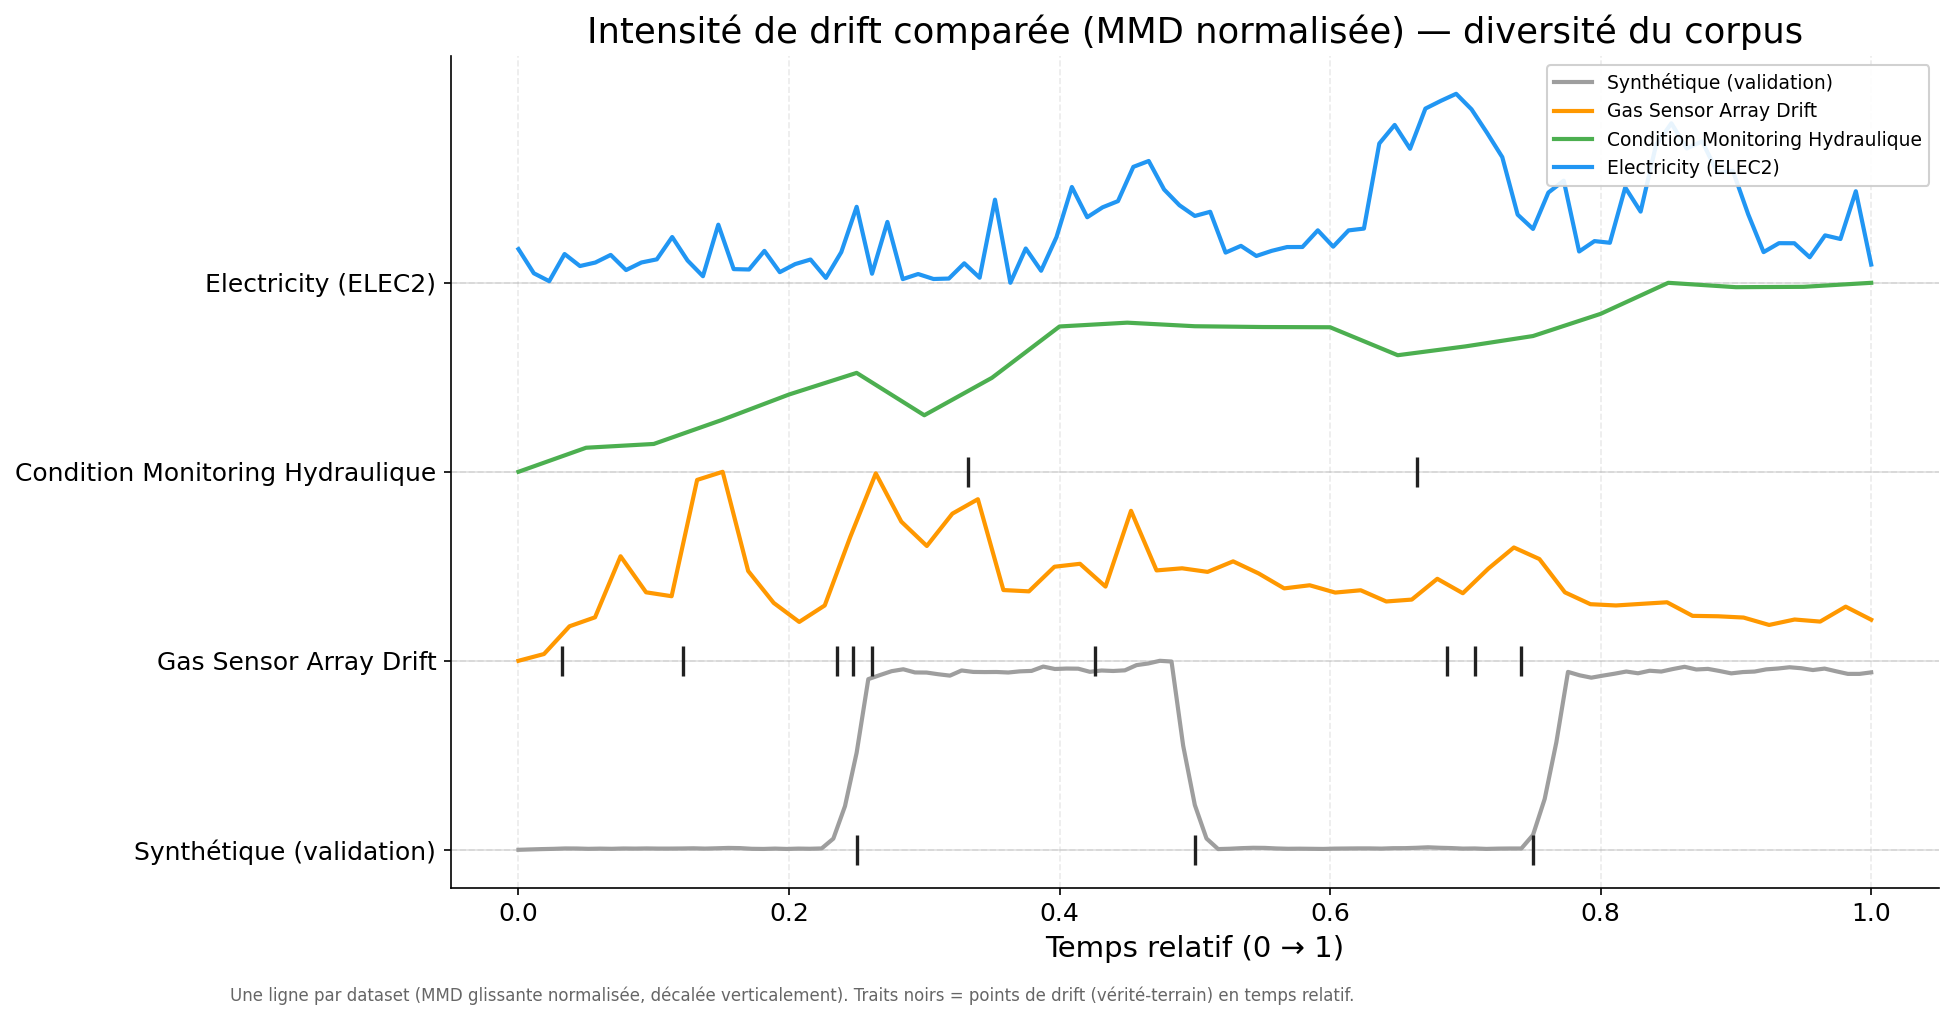

In [6]:
rows = []
for ds in DATASETS:
    data = load_char(ds)
    if data is None:
        continue
    meta = data.get("metadata", {})
    dp = data.get("drift_points")
    rows.append({
        "dataset": ds,
        "drift_type": data["drift_type_confirmed"],
        "n_samples": data["n_samples"],
        "n_features": data["n_features"],
        "n_drift_points": len(dp) if dp else 0,
        "alignment_score": data.get("alignment_score"),
        "ground_truth": meta.get("ground_truth", "?"),
        "licence": meta.get("license", "?"),
    })

df = pd.DataFrame(rows).set_index("dataset")
display(df)
display(Image(str(FIG_ROOT / "comparatif_datasets.png")))

## Bilan pour le Sprint 44

- **Chaîne de mesure validée** sur le synthétique (pics alignés sur les points imposés) → les métriques de détection (délai, FAR, taux de manqués) sont fiables.
- **Corpus diversifié** : drift récurrent (synthétique), incrémental de capteurs (Gas Sensor, Gap 1), ruptures de régime (Hydraulique), concept drift non ponctuel (Electricity).
- **Ground-truth graduée** : exacte → structurelle → absente ; les datasets à vérité-terrain ponctuelle serviront à quantifier précisément les détecteurs, Electricity servira de cas limite.
- **Dual-usage** (Gas Sensor, Hydraulique) : prépare le tandem détecteur de drift ↔ détecteur de faute (`docs/context/drift_fault_tandem.md`).

Prochaine étape (S44) : construire/évaluer des détecteurs de drift sur ce corpus, avec `SlidingWindowDriftDetector` comme baseline.